In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torchvision import datasets
from torch.utils.data import random_split
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch


First we split our dataset. We're loading the dataset using `datasets.MNIST`. This method automatically splits the dataset into train and "non-train" or test datasets. So we directly split into train and test data with this method and then we take 10,000 observations from the train dataset to create the validation dataset.

In [2]:

full_train = datasets.MNIST(root="data", train=True, download=True, transform=ToTensor())
test_data = datasets.MNIST(root="data", train=False, download=True, transform=ToTensor())

training_data, validation_data = random_split(
    full_train,
    [50_000, 10_000],
    generator=torch.Generator().manual_seed(42)
)

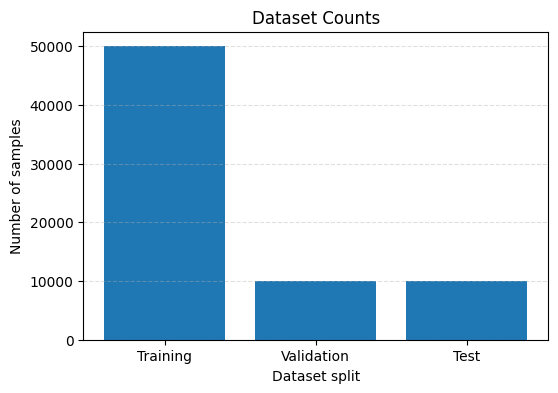

In [3]:
plt.figure(figsize=(6, 4))
dataset_counts = [len(training_data), len(validation_data), len(test_data)]
dataset_labels = ["Training", "Validation", "Test"]
plt.bar(dataset_labels, dataset_counts)
plt.title("Dataset Counts")
plt.ylabel("Number of samples")
plt.xlabel("Dataset split")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

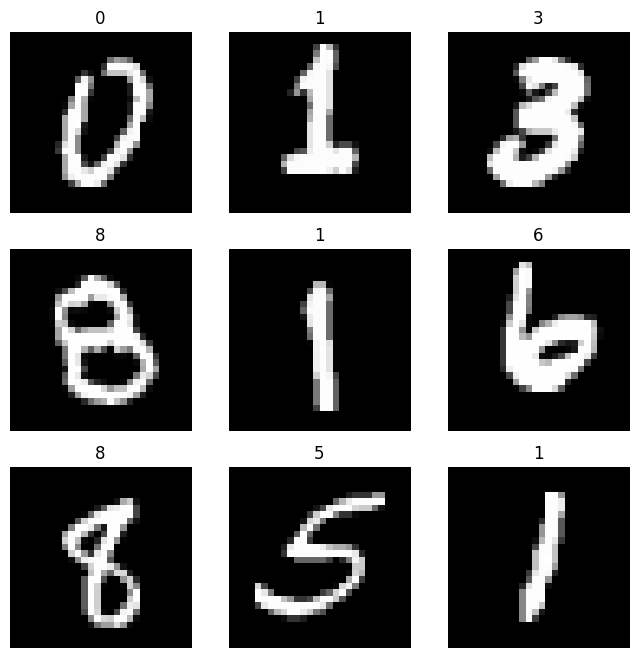

In [4]:
labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

networks = [
    { "hidden": [128, 64], "optimizer": "adam", "lr": 0.001, "batch_size": 32, "epochs": 15 },
    { "hidden": [256, 128, 64], "optimizer": "adam", "lr": 0.001, "batch_size": 32, "epochs": 5 },
    { "hidden": [128, 64], "optimizer":  "sgd", "lr": 0.01, "batch_size": 128, "epochs": 10 }
]

class FeedForwardNN(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()
        sizes = [784] + hidden_sizes + [10]
        self.layers = nn.ModuleList([
            nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)
        ])

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        for layer in self.layers[:-1]:
            x = torch.relu(layer(x))
        x = self.layers[-1](x)
        return x

https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

https://docs.pytorch.org/docs/2.10/generated/torch.nn.ModuleList.html